# Fast Accumulation Offset Explorer

This notebook is for quickly tuning `accumulation_start_offset_us` on `runs/camera/laser_selected_cycle_40px_dot12-sync-check`. It avoids the slow 50-subplot matplotlib redraw by rendering one cached PNG contact sheet with ROI zoom, optional event dilation, and per-frame contrast.

Trigger order is preserved. For this run, 10 cycles x 5 numbers = 50 ordered frames.

In [1]:
from __future__ import annotations

from functools import lru_cache
from io import BytesIO
from math import ceil
from pathlib import Path
import csv
import json
import sys
import time

import numpy as np
try:
    from IPython.display import Image as DisplayImage, clear_output, display
except ModuleNotFoundError:
    class DisplayImage:
        def __init__(self, data=None, **kwargs):
            self.data = data

    def clear_output(*args, **kwargs):
        return None

    def display(obj):
        print(type(obj).__name__)
from PIL import Image, ImageDraw, ImageFont

try:
    import cv2
except ModuleNotFoundError:
    cv2 = None


def find_repo_root(start: Path) -> Path:
    for candidate in [start, *start.parents]:
        if (candidate / "dmdcontrol").is_dir() and (candidate / "runs").is_dir():
            return candidate
    raise RuntimeError("Could not find repository root from the current notebook directory.")


REPO_ROOT = find_repo_root(Path.cwd().resolve())
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

RUN_DIR = REPO_ROOT / "runs" / "camera" / "laser_selected_cycle_40px_dot12-sync-check"
AEDAT4_PATH = RUN_DIR / "raw.aedat4"
METADATA_PATH = RUN_DIR / "metadata.json"
SUMMARY_PATH = RUN_DIR / "summary.json"
TRIGGERS_CSV_PATH = RUN_DIR / "triggers.csv"

print(f"run dir: {RUN_DIR}")
print(f"aedat4 exists: {AEDAT4_PATH.exists()}")

run dir: C:\dev\dmdcontrol\runs\camera\laser_selected_cycle_40px_dot12-sync-check
aedat4 exists: True


In [2]:
from dmdcontrol.camera.accumulation import TriggerRecord, accumulate_events_for_triggers
from dmdcontrol.camera.reprocess_aedat4 import read_aedat4_recording
from dmdcontrol.camera.runs import _events_to_arrays, _process_accumulation_triggers, _trigger_timestamps


def load_json(path: Path) -> dict:
    return json.loads(path.read_text(encoding="utf-8")) if path.exists() else {}


def load_trigger_csv(path: Path) -> list[TriggerRecord]:
    if not path.exists():
        return []
    triggers = []
    with path.open(newline="", encoding="utf-8") as handle:
        for row in csv.DictReader(handle):
            triggers.append(TriggerRecord(timestamp=int(row["timestamp"]), edge=row.get("edge") or "rising"))
    return triggers


metadata = load_json(METADATA_PATH)
summary = load_json(SUMMARY_PATH)
number_sequence = list(metadata.get("number_sequence") or [])
cycle_length = len(number_sequence) or int(metadata.get("expected_trigger_count") or 5)
default_cycles = int(metadata.get("accumulation_cycles") or 10)
default_window_us = int(
    metadata.get("accumulation_window_us")
    or metadata.get("numbers_exposure_us")
    or summary.get("window_us")
    or 1500
)

t0 = time.perf_counter()
recording = read_aedat4_recording(AEDAT4_PATH)
event_arrays = _events_to_arrays(recording.events)
event_timestamps = event_arrays["t"]
csv_triggers = load_trigger_csv(TRIGGERS_CSV_PATH)
trigger_source = "triggers.csv" if csv_triggers else "raw AEDAT4 rising triggers"
available_cycles = (
    len(csv_triggers) // max(1, cycle_length)
    if csv_triggers
    else int(recording.stats["trigger_edges"].get("rising", 0)) // max(1, cycle_length)
)
default_cycles = max(1, min(default_cycles, max(1, available_cycles)))
load_s = time.perf_counter() - t0

width, height = recording.resolution
print(f"loaded AEDAT4 in {load_s:.2f}s")
print(f"resolution: {width} x {height}")
print(f"events: {recording.stats['event_count']:,}; triggers: {recording.stats['trigger_count']:,}")
print(f"trigger edges: {recording.stats['trigger_edges']}")
print(f"trigger source for accumulation: {trigger_source}; available cycles: {available_cycles}")
print(f"cycle length: {cycle_length}; default cycles: {default_cycles}; default window: {default_window_us} us")


loaded AEDAT4 in 0.11s
resolution: 320 x 240
events: 528,257; triggers: 5,676
trigger edges: {'rising': 2838, 'triggertype.external_signal_pulse': 2838}
trigger source for accumulation: triggers.csv; available cycles: 10
cycle length: 5; default cycles: 10; default window: 1500 us


In [3]:
@lru_cache(maxsize=8)
def accumulate_cached(offset_us: int, cycles: int, window_us: int, polarity_mode: str):
    requested_cycles = int(cycles)
    requested_count = requested_cycles * int(cycle_length)
    if csv_triggers:
        selected = csv_triggers[:requested_count]
        cycle_info = {
            "mode": "trigger_csv",
            "cycle_length": int(cycle_length),
            "requested_cycles": requested_cycles,
            "available_full_cycles": int(available_cycles),
            "selected_cycle_indices": list(range(min(requested_cycles, int(available_cycles)))),
            "selected_trigger_count": len(selected),
        }
        alignment = {
            "mode": "trigger_csv",
            "source": str(TRIGGERS_CSV_PATH),
            "selected_trigger_count": len(selected),
        }
    else:
        stages = _process_accumulation_triggers(
            recording.triggers,
            event_timestamps,
            window_us=int(window_us),
            window_start_offset_us=int(offset_us),
            max_accumulation_triggers=None,
            trigger_cycle_length=cycle_length,
            accumulation_cycles=requested_cycles,
        )
        selected = stages.final
        alignment = stages.alignment_metadata
        cycle_info = stages.cycle_limit_metadata
    frames = accumulate_events_for_triggers(
        recording.events,
        selected,
        resolution=recording.resolution,
        window_us=int(window_us),
        polarity_mode=str(polarity_mode),
        window_start_offset_us=int(offset_us),
    )
    return frames, _trigger_timestamps(selected), alignment, cycle_info


def frame_values(frames: np.ndarray, view: str, tone: str, gamma: float) -> tuple[np.ndarray, bool]:
    source = frames.astype(np.float32, copy=False)
    if view == "signed":
        return source, True
    if view == "positive":
        values = np.maximum(source, 0)
    elif view == "negative":
        values = np.maximum(-source, 0)
    else:
        values = np.abs(source)
    if tone == "log":
        values = np.log1p(values)
    elif tone == "gamma":
        values = np.power(values, float(gamma))
    return values, False


def auto_roi(frames: np.ndarray, pad: int, flip_x: bool, crop_mode: str) -> tuple[slice, slice]:
    if crop_mode == "full":
        return slice(0, frames.shape[1]), slice(0, frames.shape[2])
    source = frames[:, :, ::-1] if flip_x else frames
    mask = np.any(np.abs(source) > 0, axis=0)
    if not np.any(mask):
        return slice(0, frames.shape[1]), slice(0, frames.shape[2])
    ys, xs = np.where(mask)
    y0 = max(0, int(ys.min()) - int(pad))
    y1 = min(frames.shape[1], int(ys.max()) + int(pad) + 1)
    x0 = max(0, int(xs.min()) - int(pad))
    x1 = min(frames.shape[2], int(xs.max()) + int(pad) + 1)
    if crop_mode == "square":
        side = max(y1 - y0, x1 - x0)
        cy = (y0 + y1) // 2
        cx = (x0 + x1) // 2
        y0 = max(0, min(frames.shape[1] - side, cy - side // 2))
        x0 = max(0, min(frames.shape[2] - side, cx - side // 2))
        y1 = min(frames.shape[1], y0 + side)
        x1 = min(frames.shape[2], x0 + side)
    return slice(y0, y1), slice(x0, x1)


def dilate_plane(plane: np.ndarray, dot_size: int) -> np.ndarray:
    dot_size = int(dot_size)
    if dot_size <= 1:
        return plane
    if cv2 is not None:
        kernel = np.ones((dot_size, dot_size), dtype=np.uint8)
        return cv2.dilate(plane.astype(np.float32, copy=False), kernel)
    padded = np.pad(plane, dot_size // 2, mode="edge")
    out = np.zeros_like(plane)
    for dy in range(dot_size):
        for dx in range(dot_size):
            out = np.maximum(out, padded[dy:dy + plane.shape[0], dx:dx + plane.shape[1]])
    return out


def scale_limit(values: np.ndarray, signed: bool, percentile: float) -> float:
    source = np.abs(values) if signed else values
    nonzero = source[source > 0]
    if nonzero.size == 0:
        return 1.0
    return max(float(np.percentile(nonzero, float(percentile))), 1e-6)


def frame_rgb(values: np.ndarray, signed: bool, limit: float, dot_size: int) -> np.ndarray:
    if signed:
        pos = dilate_plane(np.maximum(values, 0), dot_size)
        neg = dilate_plane(np.maximum(-values, 0), dot_size)
        pos8 = np.clip(pos / limit * 255, 0, 255).astype(np.uint8)
        neg8 = np.clip(neg / limit * 255, 0, 255).astype(np.uint8)
        rgb = np.zeros((*values.shape, 3), dtype=np.uint8)
        rgb[..., 0] = pos8
        rgb[..., 1] = neg8
        rgb[..., 2] = neg8
        return rgb
    plane = dilate_plane(values, dot_size)
    gray = np.clip(plane / limit * 255, 0, 255).astype(np.uint8)
    return np.repeat(gray[..., None], 3, axis=2)


def resize_nearest(rgb: np.ndarray, scale: int) -> Image.Image:
    image = Image.fromarray(rgb, mode="RGB")
    if int(scale) <= 1:
        return image
    return image.resize((image.width * int(scale), image.height * int(scale)), Image.Resampling.NEAREST)


def png_bytes(image: Image.Image) -> bytes:
    buffer = BytesIO()
    image.save(buffer, format="PNG", optimize=False)
    return buffer.getvalue()

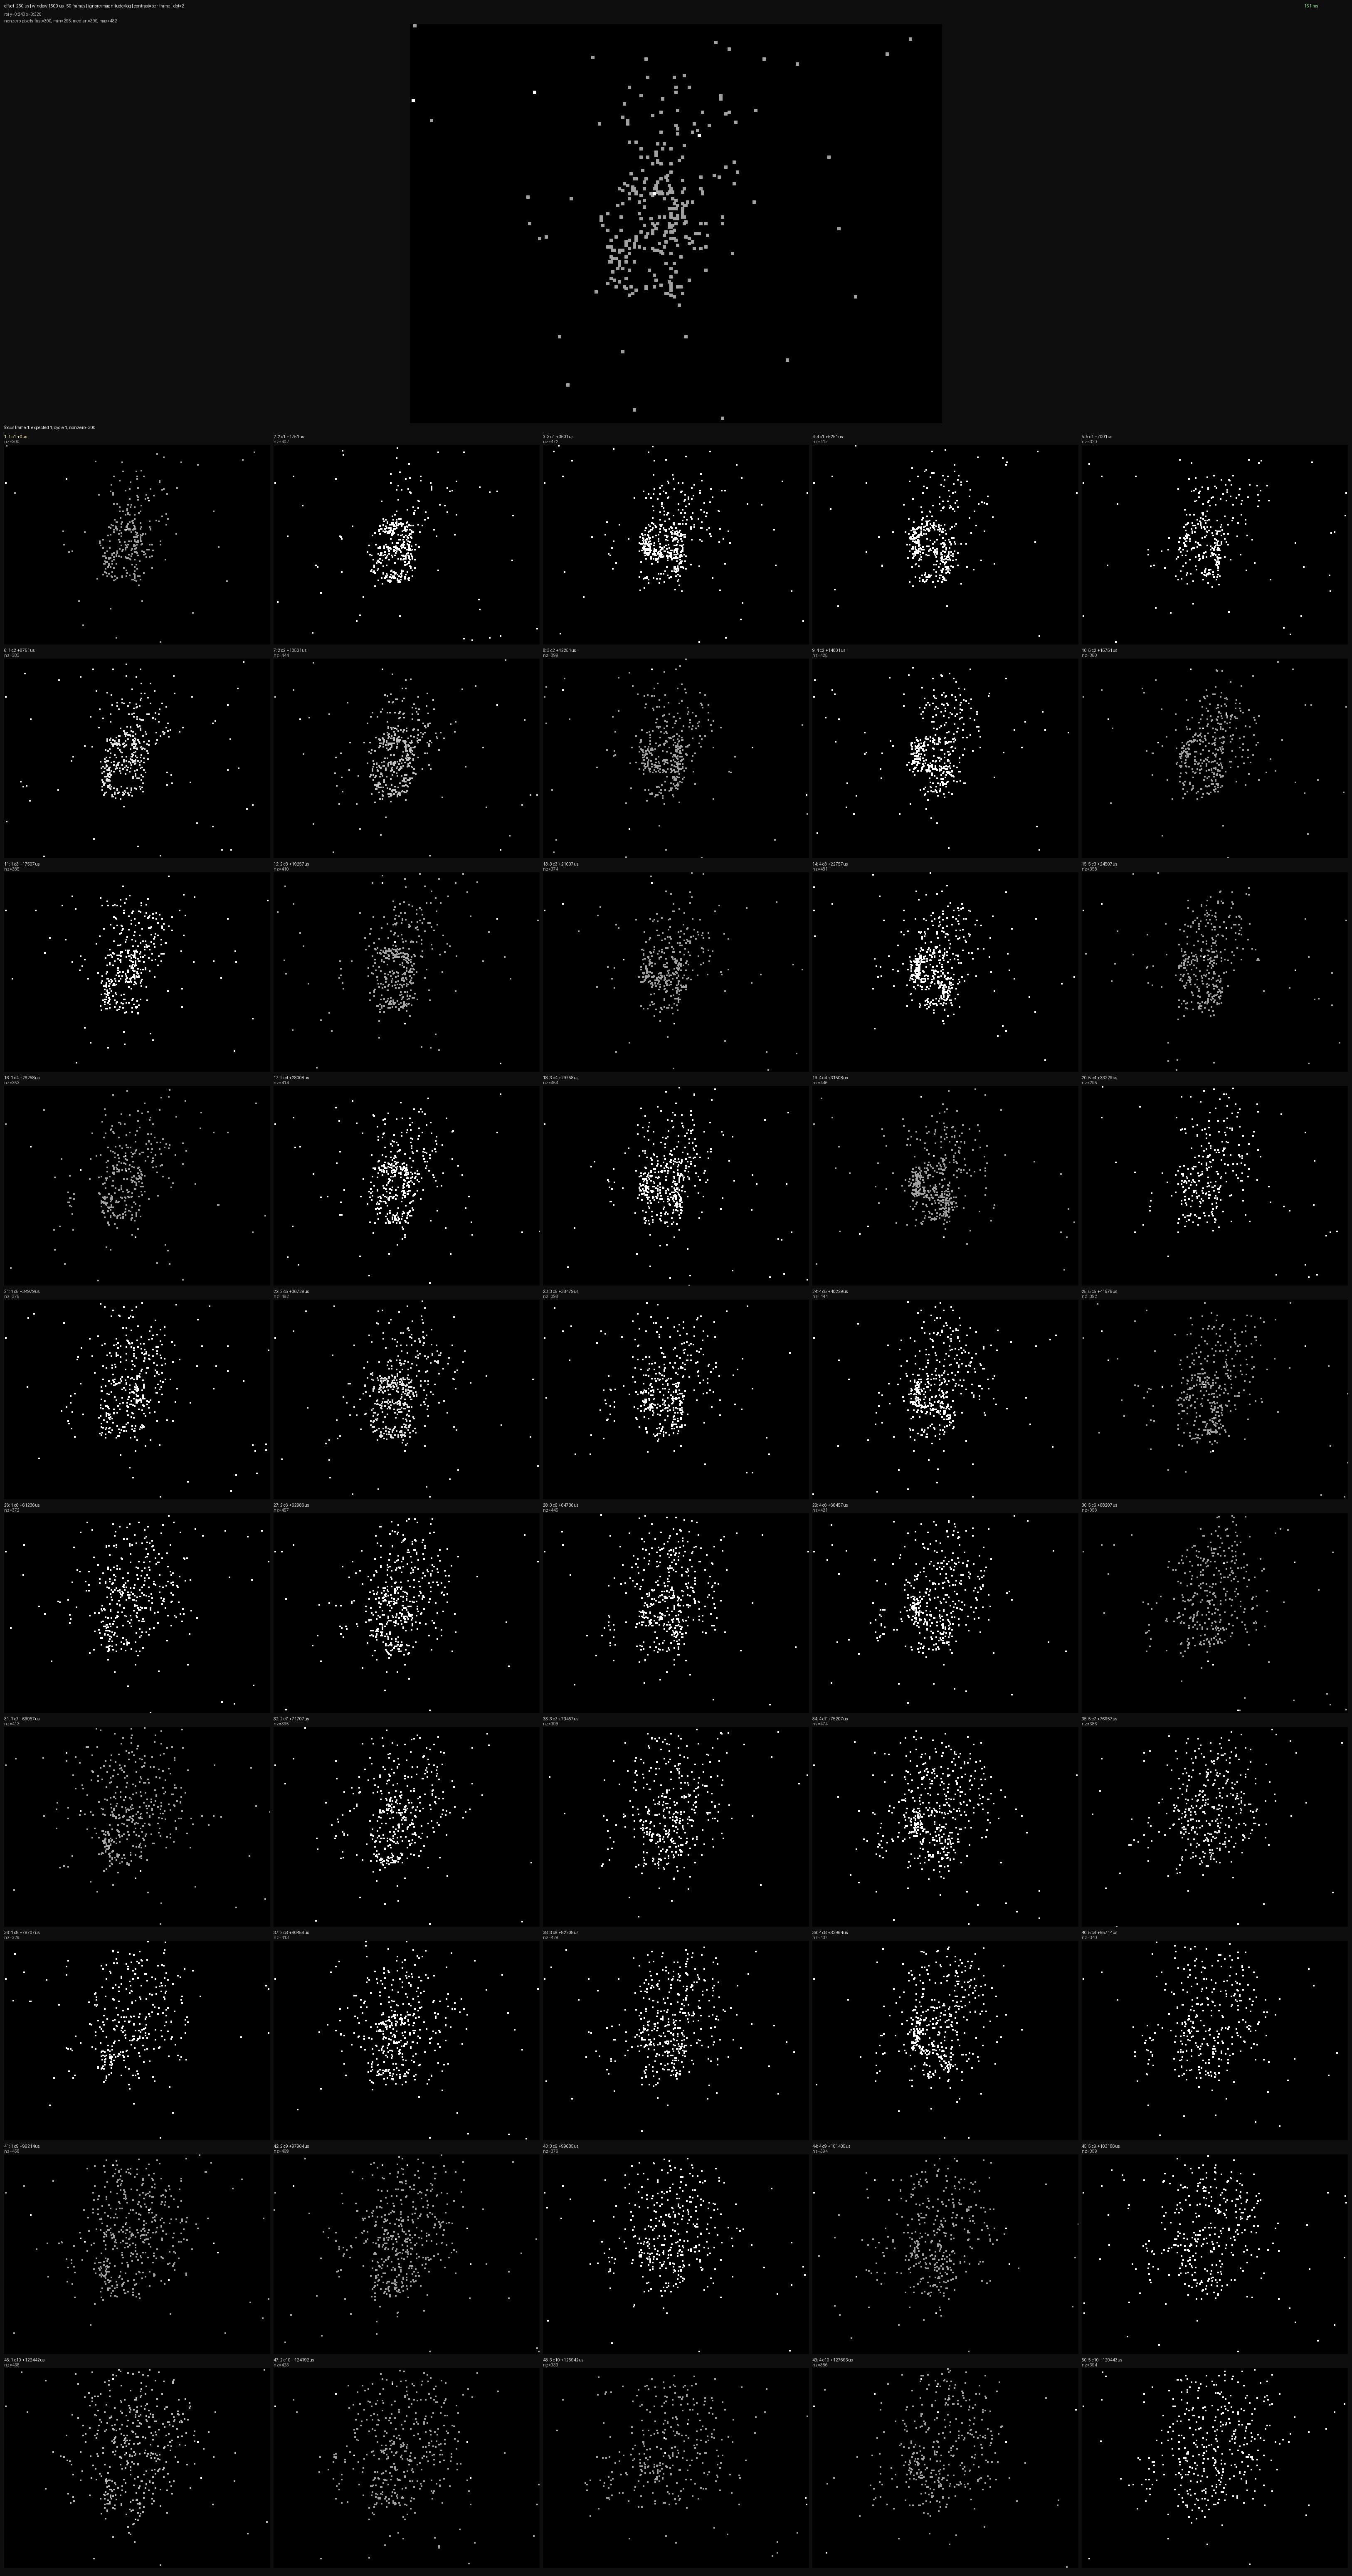

In [4]:
FONT = ImageFont.load_default()


def render_fast_sheet(
    offset_us: int = -250,
    cycles: int = default_cycles,
    window_us: int = default_window_us,
    polarity_mode: str = "ignore",
    view: str = "magnitude",
    tone: str = "log",
    gamma: float = 0.65,
    contrast: str = "per-frame",
    vmax_percentile: float = 99.0,
    crop_mode: str = "square",
    crop_pad: int = 28,
    dot_size: int = 2,
    tile_scale: int = 2,
    focus_frame: int = 1,
    focus_scale: int = 4,
    flip_x: bool = True,
):
    start = time.perf_counter()
    frames, trigger_ts, alignment, cycle_info = accumulate_cached(
        int(offset_us), int(cycles), int(window_us), str(polarity_mode)
    )
    frames_for_view = frames[:, :, ::-1] if flip_x else frames
    y_slice, x_slice = auto_roi(frames, crop_pad, flip_x=flip_x, crop_mode=crop_mode)
    cropped = frames_for_view[:, y_slice, x_slice]
    values, signed = frame_values(cropped, view=view, tone=tone, gamma=gamma)
    frame_count = values.shape[0]
    cols = max(1, int(cycle_length))
    rows = max(1, ceil(frame_count / cols))

    if contrast == "global":
        global_limit = scale_limit(values, signed=signed, percentile=vmax_percentile)
    else:
        global_limit = None

    tile_images = []
    for index in range(frame_count):
        limit = global_limit or scale_limit(values[index], signed=signed, percentile=vmax_percentile)
        tile_images.append(resize_nearest(frame_rgb(values[index], signed, limit, dot_size), tile_scale))

    tile_w = tile_images[0].width if tile_images else 1
    tile_h = tile_images[0].height if tile_images else 1
    label_h = 26
    header_h = 58
    gap = 8
    focus_index = max(0, min(frame_count - 1, int(focus_frame) - 1)) if frame_count else 0
    focus_limit = global_limit or scale_limit(values[focus_index], signed=signed, percentile=vmax_percentile)
    focus_image = resize_nearest(frame_rgb(values[focus_index], signed, focus_limit, max(1, int(dot_size))), focus_scale)

    sheet_w = cols * tile_w + (cols - 1) * gap
    sheet_h = rows * (tile_h + label_h) + (rows - 1) * gap
    canvas_w = max(sheet_w, focus_image.width) + 20
    canvas_h = header_h + focus_image.height + 22 + sheet_h + 24
    canvas = Image.new("RGB", (canvas_w, canvas_h), (14, 14, 14))
    draw = ImageDraw.Draw(canvas)

    counts = np.count_nonzero(np.abs(frames) > 0, axis=(1, 2)) if frame_count else np.array([], dtype=int)
    roi_text = f"roi y={y_slice.start}:{y_slice.stop} x={x_slice.start}:{x_slice.stop}"
    title = (
        f"offset {int(offset_us)} us | window {int(window_us)} us | {frame_count} frames | "
        f"{polarity_mode}/{view}/{tone} | contrast={contrast} | dot={int(dot_size)}"
    )
    draw.text((10, 8), title, fill=(235, 235, 235), font=FONT)
    draw.text((10, 28), roi_text, fill=(180, 180, 180), font=FONT)
    if counts.size:
        draw.text(
            (10, 44),
            f"nonzero pixels: first={int(counts[0])}, min={int(counts.min())}, median={int(np.median(counts))}, max={int(counts.max())}",
            fill=(180, 180, 180),
            font=FONT,
        )

    focus_x = (canvas_w - focus_image.width) // 2
    focus_y = header_h
    canvas.paste(focus_image, (focus_x, focus_y))
    focus_slot = focus_index % cols
    focus_cycle = focus_index // cols + 1
    focus_label = number_sequence[focus_slot] if focus_slot < len(number_sequence) else focus_slot + 1
    draw.text(
        (10, focus_y + focus_image.height + 4),
        f"focus frame {focus_index + 1}: expected {focus_label}, cycle {focus_cycle}, nonzero={int(counts[focus_index]) if counts.size else 0}",
        fill=(235, 235, 235),
        font=FONT,
    )

    first_trigger = int(trigger_ts[0]) if len(trigger_ts) else 0
    grid_y = focus_y + focus_image.height + 26
    for index, image in enumerate(tile_images):
        row = index // cols
        col = index % cols
        x = 10 + col * (tile_w + gap)
        y = grid_y + row * (tile_h + label_h + gap)
        canvas.paste(image, (x, y + label_h))
        slot = index % cols
        cycle = index // cols + 1
        label = number_sequence[slot] if slot < len(number_sequence) else slot + 1
        dt = int(trigger_ts[index] - first_trigger) if len(trigger_ts) else 0
        color = (255, 245, 170) if index == focus_index else (220, 220, 220)
        draw.text((x, y), f"{index + 1}: {label} c{cycle} +{dt}us", fill=color, font=FONT)
        if counts.size:
            draw.text((x, y + 12), f"nz={int(counts[index])}", fill=(170, 170, 170), font=FONT)

    elapsed_ms = (time.perf_counter() - start) * 1000
    draw.text((canvas_w - 115, 8), f"{elapsed_ms:.0f} ms", fill=(120, 210, 120), font=FONT)
    return canvas, frames, counts, alignment, cycle_info


image, frames, counts, alignment, cycle_info = render_fast_sheet(offset_us=-250)
display(DisplayImage(data=png_bytes(image)))

## Trigger Timeline and Bleed Diagnostics

These views answer different questions than the frame grid. The timeline shows trigger positions, accumulation windows, and event density over time. The relative activity graph shows whether events are arriving before, during, or after each trigger. The bleed matrix estimates how much spatial activity carries from one ordered frame into the next.

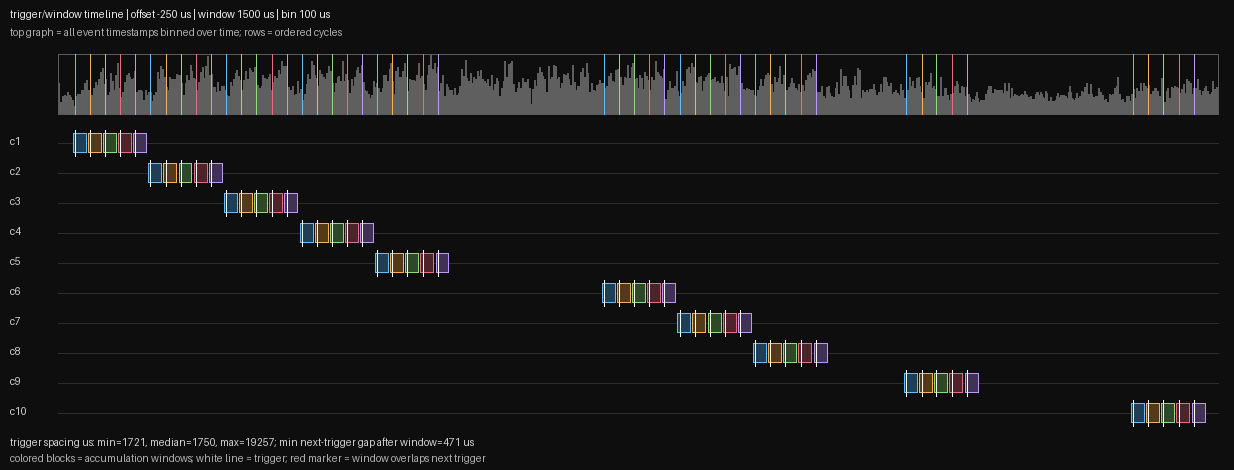

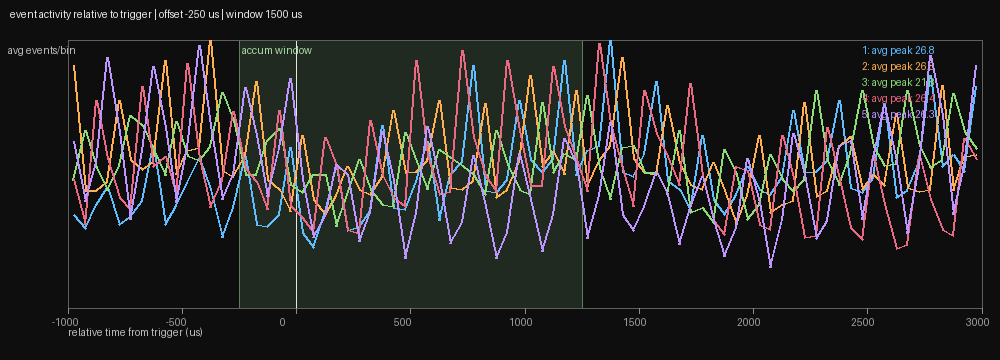

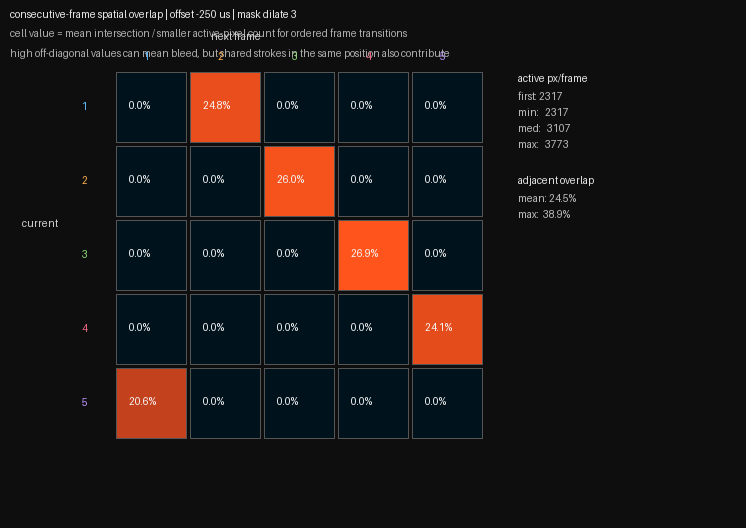

In [5]:
SLOT_COLORS = [
    (95, 190, 255),
    (255, 175, 80),
    (140, 220, 120),
    (235, 105, 130),
    (190, 150, 255),
]


def slot_color(slot: int) -> tuple[int, int, int]:
    return SLOT_COLORS[int(slot) % len(SLOT_COLORS)]


def render_trigger_timeline(
    offset_us: int = -250,
    cycles: int = default_cycles,
    window_us: int = default_window_us,
    bin_us: int = 100,
    margin_us: int = 500,
    polarity_mode: str = "ignore",
):
    frames, trigger_ts, alignment, cycle_info = accumulate_cached(
        int(offset_us), int(cycles), int(window_us), str(polarity_mode)
    )
    trigger_ts = np.asarray(trigger_ts, dtype=np.int64)
    if trigger_ts.size == 0:
        return Image.new("RGB", (900, 120), (14, 14, 14))

    # Keep the absolute-time axis anchored to triggers, not to shifted windows.
    # Otherwise changing offset re-centers the graph and makes trigger lines look like they move backward.
    axis_offset_min_us = -1500
    axis_offset_max_us = 750
    start = int(np.min(trigger_ts) + min(axis_offset_min_us, int(offset_us), 0) - int(margin_us))
    end = int(np.max(trigger_ts) + max(axis_offset_max_us, int(offset_us), 0) + int(window_us) + int(margin_us))
    bins = np.arange(start, end + int(bin_us), int(bin_us), dtype=np.int64)
    if bins.size < 2:
        bins = np.array([start, end + 1], dtype=np.int64)
    event_counts, _ = np.histogram(event_timestamps, bins=bins)

    plot_w = 1160
    left = 58
    right = 16
    top_h = 128
    row_h = 30
    footer_h = 42
    rows = max(1, ceil(len(trigger_ts) / cycle_length))
    canvas = Image.new("RGB", (plot_w + left + right, top_h + rows * row_h + footer_h), (14, 14, 14))
    draw = ImageDraw.Draw(canvas)

    def x_of(t_us: int | float) -> int:
        return int(left + (float(t_us) - start) / max(1, end - start) * plot_w)

    draw.text((10, 8), f"trigger/window timeline | offset {int(offset_us)} us | window {int(window_us)} us | bin {int(bin_us)} us", fill=(235, 235, 235), font=FONT)
    draw.text((10, 26), "top graph = all event timestamps binned over time; rows = ordered cycles", fill=(175, 175, 175), font=FONT)

    hist_top = 54
    hist_h = 60
    max_count = max(1, int(event_counts.max()) if event_counts.size else 1)
    for idx, count in enumerate(event_counts):
        x0 = x_of(int(bins[idx]))
        x1 = max(x0 + 1, x_of(int(bins[idx + 1])))
        h = int((int(count) / max_count) * hist_h)
        draw.rectangle((x0, hist_top + hist_h - h, x1, hist_top + hist_h), fill=(95, 95, 95))
    draw.rectangle((left, hist_top, left + plot_w, hist_top + hist_h), outline=(90, 90, 90))

    for index, trigger in enumerate(trigger_ts):
        slot = index % cycle_length
        color = slot_color(slot)
        x = x_of(int(trigger))
        draw.line((x, hist_top, x, hist_top + hist_h), fill=color)

    for cycle in range(rows):
        y = top_h + cycle * row_h
        draw.text((10, y + 7), f"c{cycle + 1}", fill=(210, 210, 210), font=FONT)
        draw.line((left, y + row_h // 2, left + plot_w, y + row_h // 2), fill=(45, 45, 45))
        for slot in range(cycle_length):
            index = cycle * cycle_length + slot
            if index >= len(trigger_ts):
                break
            trigger = int(trigger_ts[index])
            win_start = trigger + int(offset_us)
            win_end = win_start + int(window_us)
            x0 = x_of(win_start)
            x1 = x_of(win_end)
            xt = x_of(trigger)
            color = slot_color(slot)
            fill = tuple(max(25, c // 3) for c in color)
            draw.rectangle((x0, y + 5, x1, y + row_h - 6), fill=fill, outline=color)
            draw.line((xt, y + 2, xt, y + row_h - 2), fill=(255, 255, 255))
            if index + 1 < len(trigger_ts) and win_end > int(trigger_ts[index + 1]):
                draw.line((x1, y + 3, x1, y + row_h - 3), fill=(255, 80, 80), width=2)

    dt = np.diff(trigger_ts)
    footer_y = top_h + rows * row_h + 8
    if dt.size:
        min_gap_after_window = int(np.min(dt - int(window_us) - int(offset_us)))
        draw.text(
            (10, footer_y),
            f"trigger spacing us: min={int(dt.min())}, median={float(np.median(dt)):.0f}, max={int(dt.max())}; min next-trigger gap after window={min_gap_after_window} us",
            fill=(210, 210, 210),
            font=FONT,
        )
    draw.text((10, footer_y + 16), "colored blocks = accumulation windows; white line = trigger; red marker = window overlaps next trigger", fill=(175, 175, 175), font=FONT)
    return canvas


def render_relative_activity(
    offset_us: int = -250,
    cycles: int = default_cycles,
    window_us: int = default_window_us,
    pre_us: int = 1000,
    post_us: int = 3000,
    bin_us: int = 50,
    polarity_mode: str = "ignore",
):
    frames, trigger_ts, alignment, cycle_info = accumulate_cached(
        int(offset_us), int(cycles), int(window_us), str(polarity_mode)
    )
    trigger_ts = np.asarray(trigger_ts, dtype=np.int64)
    rel_edges = np.arange(-int(pre_us), int(post_us) + int(bin_us), int(bin_us), dtype=np.int64)
    rel_centers = (rel_edges[:-1] + rel_edges[1:]) / 2.0
    slot_counts = np.zeros((cycle_length, len(rel_centers)), dtype=np.float32)
    slot_seen = np.zeros(cycle_length, dtype=np.int64)
    for index, trigger in enumerate(trigger_ts):
        slot = index % cycle_length
        hist, _ = np.histogram(event_timestamps, bins=trigger + rel_edges)
        slot_counts[slot] += hist.astype(np.float32)
        slot_seen[slot] += 1
    for slot in range(cycle_length):
        if slot_seen[slot] > 0:
            slot_counts[slot] /= slot_seen[slot]

    W, H = 1000, 360
    left, right, top, bottom = 68, 18, 40, 52
    plot_w = W - left - right
    plot_h = H - top - bottom
    canvas = Image.new("RGB", (W, H), (14, 14, 14))
    draw = ImageDraw.Draw(canvas)

    def x_of(rel_us: int | float) -> int:
        return int(left + (float(rel_us) + int(pre_us)) / max(1, int(pre_us) + int(post_us)) * plot_w)

    max_y = max(1.0, float(slot_counts.max()))

    def y_of(count: int | float) -> int:
        return int(top + plot_h - (float(count) / max_y) * plot_h)

    win_x0 = x_of(int(offset_us))
    win_x1 = x_of(int(offset_us) + int(window_us))
    draw.rectangle((win_x0, top, win_x1, top + plot_h), fill=(32, 42, 32), outline=(90, 130, 90))
    draw.line((x_of(0), top, x_of(0), top + plot_h), fill=(230, 230, 230))
    draw.rectangle((left, top, left + plot_w, top + plot_h), outline=(95, 95, 95))
    draw.text((10, 8), f"event activity relative to trigger | offset {int(offset_us)} us | window {int(window_us)} us", fill=(235, 235, 235), font=FONT)
    draw.text((left, H - 34), "relative time from trigger (us)", fill=(190, 190, 190), font=FONT)
    draw.text((8, top + 4), "avg events/bin", fill=(190, 190, 190), font=FONT)
    for tick in range(-int(pre_us), int(post_us) + 1, 500):
        x = x_of(tick)
        draw.line((x, top + plot_h, x, top + plot_h + 5), fill=(140, 140, 140))
        draw.text((x - 16, top + plot_h + 8), str(tick), fill=(160, 160, 160), font=FONT)

    for slot in range(cycle_length):
        points = [(x_of(x), y_of(y)) for x, y in zip(rel_centers, slot_counts[slot], strict=False)]
        if len(points) >= 2:
            draw.line(points, fill=slot_color(slot), width=2)
        label = number_sequence[slot] if slot < len(number_sequence) else slot + 1
        draw.text((W - 138, 44 + slot * 16), f"{label}: avg peak {float(slot_counts[slot].max()):.1f}", fill=slot_color(slot), font=FONT)
    draw.text((win_x0 + 3, top + 4), "accum window", fill=(170, 220, 170), font=FONT)
    return canvas


def render_bleed_matrix(
    offset_us: int = -250,
    cycles: int = default_cycles,
    window_us: int = default_window_us,
    polarity_mode: str = "ignore",
    mask_dilate: int = 3,
):
    frames, trigger_ts, alignment, cycle_info = accumulate_cached(
        int(offset_us), int(cycles), int(window_us), str(polarity_mode)
    )
    masks = np.abs(frames) > 0
    if int(mask_dilate) > 1:
        masks = np.stack([dilate_plane(mask.astype(np.float32), int(mask_dilate)) > 0 for mask in masks], axis=0)
    active = masks.reshape(masks.shape[0], -1).sum(axis=1) if masks.size else np.array([], dtype=np.int64)
    matrix_values = [[[] for _ in range(cycle_length)] for _ in range(cycle_length)]
    adjacent_scores = []
    for index in range(max(0, len(masks) - 1)):
        a = index % cycle_length
        b = (index + 1) % cycle_length
        inter = int(np.logical_and(masks[index], masks[index + 1]).sum())
        denom = max(1, int(min(active[index], active[index + 1])))
        score = inter / denom
        matrix_values[a][b].append(score)
        adjacent_scores.append(score)

    matrix = np.zeros((cycle_length, cycle_length), dtype=np.float32)
    for r in range(cycle_length):
        for c in range(cycle_length):
            if matrix_values[r][c]:
                matrix[r, c] = float(np.mean(matrix_values[r][c]))

    cell = 74
    left, top = 116, 72
    W = left + cycle_length * cell + 260
    H = top + cycle_length * cell + 86
    canvas = Image.new("RGB", (W, H), (14, 14, 14))
    draw = ImageDraw.Draw(canvas)
    draw.text((10, 8), f"consecutive-frame spatial overlap | offset {int(offset_us)} us | mask dilate {int(mask_dilate)}", fill=(235, 235, 235), font=FONT)
    draw.text((10, 27), "cell value = mean intersection / smaller active-pixel count for ordered frame transitions", fill=(175, 175, 175), font=FONT)
    draw.text((10, 47), "high off-diagonal values can mean bleed, but shared strokes in the same position also contribute", fill=(175, 175, 175), font=FONT)

    for slot in range(cycle_length):
        label = str(number_sequence[slot] if slot < len(number_sequence) else slot + 1)
        draw.text((left + slot * cell + 28, top - 22), label, fill=slot_color(slot), font=FONT)
        draw.text((left - 34, top + slot * cell + 28), label, fill=slot_color(slot), font=FONT)
    draw.text((left + 95, top - 42), "next frame", fill=(210, 210, 210), font=FONT)
    draw.text((22, top + 145), "current", fill=(210, 210, 210), font=FONT)

    max_value = max(0.01, float(matrix.max()))
    for r in range(cycle_length):
        for c in range(cycle_length):
            value = float(matrix[r, c])
            intensity = int(np.clip(value / max_value * 255, 0, 255))
            fill = (intensity, max(18, intensity // 3), 28)
            x0 = left + c * cell
            y0 = top + r * cell
            draw.rectangle((x0, y0, x0 + cell - 4, y0 + cell - 4), fill=fill, outline=(85, 85, 85))
            draw.text((x0 + 13, y0 + 27), f"{value * 100:.1f}%", fill=(245, 245, 245), font=FONT)

    stats_x = left + cycle_length * cell + 32
    if active.size:
        draw.text((stats_x, top), f"active px/frame", fill=(230, 230, 230), font=FONT)
        draw.text((stats_x, top + 18), f"first: {int(active[0])}", fill=(190, 190, 190), font=FONT)
        draw.text((stats_x, top + 34), f"min:   {int(active.min())}", fill=(190, 190, 190), font=FONT)
        draw.text((stats_x, top + 50), f"med:   {int(np.median(active))}", fill=(190, 190, 190), font=FONT)
        draw.text((stats_x, top + 66), f"max:   {int(active.max())}", fill=(190, 190, 190), font=FONT)
    if adjacent_scores:
        draw.text((stats_x, top + 102), f"adjacent overlap", fill=(230, 230, 230), font=FONT)
        draw.text((stats_x, top + 120), f"mean: {float(np.mean(adjacent_scores)) * 100:.1f}%", fill=(190, 190, 190), font=FONT)
        draw.text((stats_x, top + 136), f"max:  {float(np.max(adjacent_scores)) * 100:.1f}%", fill=(190, 190, 190), font=FONT)
    return canvas


timeline_image = render_trigger_timeline(offset_us=-250)
activity_image = render_relative_activity(offset_us=-250)
bleed_image = render_bleed_matrix(offset_us=-250)
display(DisplayImage(data=png_bytes(timeline_image)))
display(DisplayImage(data=png_bytes(activity_image)))
display(DisplayImage(data=png_bytes(bleed_image)))

## Interactive Controls

Defaults are tuned to make sparse event frames visible: ROI crop, per-frame contrast, log tone, and dot dilation. Switch contrast to `global` when you want brightness comparisons to be physically meaningful across frames.

In [6]:
try:
    import ipywidgets as widgets
    HAVE_WIDGETS = True
except ModuleNotFoundError:
    HAVE_WIDGETS = False
    print("ipywidgets is not installed in this kernel. Run `%pip install ipywidgets`, restart the kernel, then rerun this notebook.")


if HAVE_WIDGETS:
    offset_slider = widgets.IntSlider(
        value=-180,
        min=-1500,
        max=750,
        step=25,
        description="offset us",
        continuous_update=True,
        layout=widgets.Layout(width="560px"),
    )
    cycles_slider = widgets.IntSlider(
        value=default_cycles,
        min=1,
        max=max(1, min(20, int(available_cycles))),
        step=1,
        description="cycles",
        continuous_update=False,
        layout=widgets.Layout(width="560px"),
    )
    window_slider = widgets.IntSlider(
        value=1750,
        min=100,
        max=max(2500, default_window_us * 2),
        step=25,
        description="window us",
        continuous_update=False,
        layout=widgets.Layout(width="560px"),
    )
    focus_slider = widgets.IntSlider(
        value=1,
        min=1,
        max=max(1, default_cycles * cycle_length),
        step=1,
        description="focus",
        continuous_update=True,
        layout=widgets.Layout(width="560px"),
    )
    polarity_dropdown = widgets.Dropdown(value="ignore", options=["ignore", "signed", "positive"], description="accum")
    view_dropdown = widgets.Dropdown(value="magnitude", options=["magnitude", "positive", "negative", "signed"], description="view")
    tone_dropdown = widgets.Dropdown(value="log", options=["log", "gamma", "linear"], description="tone")
    contrast_dropdown = widgets.Dropdown(value="per-frame", options=["per-frame", "global"], description="contrast")
    crop_dropdown = widgets.Dropdown(value="square", options=["square", "auto", "full"], description="crop")
    gamma_slider = widgets.FloatSlider(value=0.65, min=0.2, max=1.5, step=0.05, description="gamma", continuous_update=False, layout=widgets.Layout(width="560px"))
    vmax_slider = widgets.FloatSlider(value=99.0, min=90.0, max=100.0, step=0.1, description="vmax %", continuous_update=False, layout=widgets.Layout(width="560px"))
    pad_slider = widgets.IntSlider(value=28, min=0, max=80, step=2, description="crop pad", continuous_update=False, layout=widgets.Layout(width="560px"))
    dot_slider = widgets.IntSlider(value=2, min=1, max=6, step=1, description="dot size", continuous_update=True, layout=widgets.Layout(width="560px"))
    tile_scale_slider = widgets.IntSlider(value=2, min=1, max=4, step=1, description="tile scale", continuous_update=False, layout=widgets.Layout(width="560px"))
    focus_scale_slider = widgets.IntSlider(value=4, min=2, max=8, step=1, description="focus scale", continuous_update=False, layout=widgets.Layout(width="560px"))
    flip_checkbox = widgets.Checkbox(value=True, description="flip x for viewing")
    out = widgets.Output()

    def sync_focus_max(*_):
        focus_slider.max = max(1, cycles_slider.value * cycle_length)
        if focus_slider.value > focus_slider.max:
            focus_slider.value = focus_slider.max

    def redraw(_=None):
        sync_focus_max()
        with out:
            clear_output(wait=True)
            image, frames, counts, alignment, cycle_info = render_fast_sheet(
                offset_us=offset_slider.value,
                cycles=cycles_slider.value,
                window_us=window_slider.value,
                polarity_mode=polarity_dropdown.value,
                view=view_dropdown.value,
                tone=tone_dropdown.value,
                gamma=gamma_slider.value,
                contrast=contrast_dropdown.value,
                vmax_percentile=vmax_slider.value,
                crop_mode=crop_dropdown.value,
                crop_pad=pad_slider.value,
                dot_size=dot_slider.value,
                tile_scale=tile_scale_slider.value,
                focus_frame=focus_slider.value,
                focus_scale=focus_scale_slider.value,
                flip_x=flip_checkbox.value,
            )
            display(DisplayImage(data=png_bytes(image)))

    for widget in [
        offset_slider,
        cycles_slider,
        window_slider,
        focus_slider,
        polarity_dropdown,
        view_dropdown,
        tone_dropdown,
        contrast_dropdown,
        crop_dropdown,
        gamma_slider,
        vmax_slider,
        pad_slider,
        dot_slider,
        tile_scale_slider,
        focus_scale_slider,
        flip_checkbox,
    ]:
        widget.observe(redraw, names="value")

    controls = widgets.VBox([
        offset_slider,
        cycles_slider,
        window_slider,
        focus_slider,
        widgets.HBox([polarity_dropdown, view_dropdown, tone_dropdown, contrast_dropdown, crop_dropdown]),
        gamma_slider,
        vmax_slider,
        pad_slider,
        widgets.HBox([dot_slider, tile_scale_slider, focus_scale_slider, flip_checkbox]),
    ])
    display(controls)
    display(out)
    redraw()
else:
    image, frames, counts, alignment, cycle_info = render_fast_sheet(offset_us=-250)
    display(DisplayImage(data=png_bytes(image)))

Output()

## Interactive Timeline and Bleed Controls

Use this when the frame grid looks bad and you want to separate timing problems from image-rendering problems. These controls update on release instead of continuously, which keeps the notebook responsive.

In [7]:
try:
    import ipywidgets as widgets
    HAVE_WIDGETS = True
except ModuleNotFoundError:
    HAVE_WIDGETS = False


if HAVE_WIDGETS:
    diag_offset_slider = widgets.IntSlider(
        value=-250,
        min=-1500,
        max=750,
        step=25,
        description="offset us",
        continuous_update=False,
        layout=widgets.Layout(width="560px"),
    )
    diag_window_slider = widgets.IntSlider(
        value=default_window_us,
        min=100,
        max=max(2500, default_window_us * 2),
        step=25,
        description="window us",
        continuous_update=False,
        layout=widgets.Layout(width="560px"),
    )
    diag_cycles_slider = widgets.IntSlider(
        value=default_cycles,
        min=1,
        max=max(1, min(20, recording.stats["trigger_edges"].get("rising", 0) // max(1, cycle_length))),
        step=1,
        description="cycles",
        continuous_update=False,
        layout=widgets.Layout(width="560px"),
    )
    diag_bin_slider = widgets.IntSlider(value=100, min=25, max=500, step=25, description="time bin", continuous_update=False, layout=widgets.Layout(width="560px"))
    diag_pre_slider = widgets.IntSlider(value=1000, min=0, max=3000, step=100, description="pre us", continuous_update=False, layout=widgets.Layout(width="560px"))
    diag_post_slider = widgets.IntSlider(value=3000, min=500, max=6000, step=100, description="post us", continuous_update=False, layout=widgets.Layout(width="560px"))
    diag_mask_slider = widgets.IntSlider(value=3, min=1, max=9, step=1, description="mask dilate", continuous_update=False, layout=widgets.Layout(width="560px"))
    diag_polarity_dropdown = widgets.Dropdown(value="ignore", options=["ignore", "signed", "positive"], description="accum")
    diag_out = widgets.Output()

    def redraw_diagnostics(_=None):
        with diag_out:
            clear_output(wait=True)
            timeline_image = render_trigger_timeline(
                offset_us=diag_offset_slider.value,
                cycles=diag_cycles_slider.value,
                window_us=diag_window_slider.value,
                bin_us=diag_bin_slider.value,
                polarity_mode=diag_polarity_dropdown.value,
            )
            activity_image = render_relative_activity(
                offset_us=diag_offset_slider.value,
                cycles=diag_cycles_slider.value,
                window_us=diag_window_slider.value,
                pre_us=diag_pre_slider.value,
                post_us=diag_post_slider.value,
                bin_us=max(25, diag_bin_slider.value // 2),
                polarity_mode=diag_polarity_dropdown.value,
            )
            bleed_image = render_bleed_matrix(
                offset_us=diag_offset_slider.value,
                cycles=diag_cycles_slider.value,
                window_us=diag_window_slider.value,
                polarity_mode=diag_polarity_dropdown.value,
                mask_dilate=diag_mask_slider.value,
            )
            display(DisplayImage(data=png_bytes(timeline_image)))
            display(DisplayImage(data=png_bytes(activity_image)))
            display(DisplayImage(data=png_bytes(bleed_image)))

    for widget in [
        diag_offset_slider,
        diag_window_slider,
        diag_cycles_slider,
        diag_bin_slider,
        diag_pre_slider,
        diag_post_slider,
        diag_mask_slider,
        diag_polarity_dropdown,
    ]:
        widget.observe(redraw_diagnostics, names="value")

    display(widgets.VBox([
        diag_offset_slider,
        diag_window_slider,
        diag_cycles_slider,
        widgets.HBox([diag_bin_slider, diag_mask_slider, diag_polarity_dropdown]),
        widgets.HBox([diag_pre_slider, diag_post_slider]),
    ]))
    display(diag_out)
    redraw_diagnostics()
else:
    print("ipywidgets is not installed in this kernel. Static diagnostics were rendered above.")

Output()

## Offset Score Table

This is a quick numerical scan. It does not pick a cycle or reorder frames; it only reports how many nonzero pixels each offset produces in the first `N x 5` ordered frames.

In [8]:
def offset_score_table(offsets=range(-1000, 501, 50), cycles=default_cycles, window_us=1750, polarity_mode="ignore"):
    rows = []
    for offset in offsets:
        frames, trigger_ts, alignment, cycle_info = accumulate_cached(int(offset), int(cycles), int(window_us), str(polarity_mode))
        counts = np.count_nonzero(np.abs(frames) > 0, axis=(1, 2))
        first_cycle = counts[:cycle_length] if counts.size else np.array([], dtype=int)
        rows.append({
            "offset_us": int(offset),
            "frame1": int(counts[0]) if counts.size else 0,
            "first_cycle_min": int(first_cycle.min()) if first_cycle.size else 0,
            "first_cycle_median": int(np.median(first_cycle)) if first_cycle.size else 0,
            "all_min": int(counts.min()) if counts.size else 0,
            "all_median": int(np.median(counts)) if counts.size else 0,
            "all_max": int(counts.max()) if counts.size else 0,
        })
    return sorted(rows, key=lambda row: (row["first_cycle_min"], row["frame1"], row["all_median"]), reverse=True)


scores = offset_score_table()
for row in scores[:12]:
    print(row)

{'offset_us': -350, 'frame1': 399, 'first_cycle_min': 399, 'first_cycle_median': 499, 'all_min': 368, 'all_median': 476, 'all_max': 576}
{'offset_us': -400, 'frame1': 396, 'first_cycle_min': 396, 'first_cycle_median': 438, 'all_min': 389, 'all_median': 473, 'all_max': 576}
{'offset_us': -300, 'frame1': 395, 'first_cycle_min': 395, 'first_cycle_median': 481, 'all_min': 385, 'all_median': 480, 'all_max': 568}
{'offset_us': -150, 'frame1': 428, 'first_cycle_min': 391, 'first_cycle_median': 501, 'all_min': 328, 'all_median': 484, 'all_max': 585}
{'offset_us': -200, 'frame1': 426, 'first_cycle_min': 389, 'first_cycle_median': 461, 'all_min': 372, 'all_median': 483, 'all_max': 582}
{'offset_us': -100, 'frame1': 423, 'first_cycle_min': 372, 'first_cycle_median': 494, 'all_min': 361, 'all_median': 487, 'all_max': 576}
{'offset_us': -250, 'frame1': 395, 'first_cycle_min': 363, 'first_cycle_median': 485, 'all_min': 358, 'all_median': 485, 'all_max': 569}
{'offset_us': -550, 'frame1': 356, 'first

## Automatic Offset/Window Scan

This ranks `(accumulation_start_offset_us, window_us)` pairs without reordering triggers. The balanced score is a starting point; compare it with the signal-heavy and low-bleed lists before choosing a value for a real run.

In [9]:
def _dilate_mask(mask: np.ndarray, size: int = 3) -> np.ndarray:
    if int(size) <= 1:
        return mask.astype(bool, copy=False)
    return dilate_plane(mask.astype(np.float32), int(size)) > 0


def timing_candidate_metrics(offset_us: int, window_us: int, cycles: int = default_cycles, polarity_mode: str = "ignore") -> dict:
    frames, trigger_ts, alignment, cycle_info = accumulate_cached(
        int(offset_us), int(cycles), int(window_us), str(polarity_mode)
    )
    masks = np.abs(frames) > 0
    counts = masks.sum(axis=(1, 2)).astype(np.float32)
    trigger_ts = np.asarray(trigger_ts, dtype=np.int64)
    if counts.size == 0:
        return {"valid": False, "offset_us": int(offset_us), "window_us": int(window_us)}

    first_cycle = counts[:cycle_length]
    slot_counts = counts[: (counts.size // cycle_length) * cycle_length].reshape((-1, cycle_length))
    slot_cv = np.std(slot_counts, axis=0) / np.maximum(1.0, np.mean(slot_counts, axis=0))
    dilated = np.stack([_dilate_mask(mask, 3) for mask in masks], axis=0)
    overlaps = []
    for index in range(len(dilated) - 1):
        intersection = np.logical_and(dilated[index], dilated[index + 1]).sum()
        denominator = max(1, min(dilated[index].sum(), dilated[index + 1].sum()))
        overlaps.append(float(intersection / denominator))
    overlaps = np.asarray(overlaps, dtype=np.float32)
    spacing = np.diff(trigger_ts).astype(np.float32)
    min_gap_after_window = float(np.min(spacing - int(offset_us) - int(window_us))) if spacing.size else 9999.0

    signal_score = (
        np.log1p(float(np.median(counts)))
        + 0.75 * np.log1p(float(counts[0]))
        + 0.50 * np.log1p(float(np.min(first_cycle)))
    )
    consistency_penalty = 1.5 * float(np.mean(slot_cv))
    bleed_penalty = (3.0 * float(np.mean(overlaps)) + 1.0 * float(np.max(overlaps))) if overlaps.size else 0.0
    gap_penalty = max(0.0, -min_gap_after_window / 250.0) + max(0.0, (100.0 - min_gap_after_window) / 1000.0)

    return {
        "valid": True,
        "offset_us": int(offset_us),
        "window_us": int(window_us),
        "balanced_score": float(signal_score - consistency_penalty - bleed_penalty - gap_penalty),
        "signal_heavy_score": float(signal_score - 0.5 * consistency_penalty - 0.4 * bleed_penalty - gap_penalty),
        "low_bleed_score": float(signal_score - consistency_penalty - 2.5 * bleed_penalty - 1.5 * gap_penalty),
        "frame1_active": int(counts[0]),
        "first_cycle_min_active": int(np.min(first_cycle)),
        "median_active": int(np.median(counts)),
        "adjacent_overlap_mean_pct": float(np.mean(overlaps) * 100.0) if overlaps.size else 0.0,
        "adjacent_overlap_max_pct": float(np.max(overlaps) * 100.0) if overlaps.size else 0.0,
        "min_gap_after_window_us": int(round(min_gap_after_window)),
        "slot_cv_mean": float(np.mean(slot_cv)),
    }


def run_automatic_timing_scan(offsets=range(-500, 101, 25), windows=range(1200, 1801, 50), cycles=default_cycles, polarity_mode="ignore"):
    started = time.perf_counter()
    rows = []
    for window_us in windows:
        for offset_us in offsets:
            row = timing_candidate_metrics(offset_us, window_us, cycles=cycles, polarity_mode=polarity_mode)
            if row.get("valid"):
                rows.append(row)
    print(f"scanned {len(rows)} candidates in {time.perf_counter() - started:.1f}s")
    return rows


def print_ranked(rows, key: str, title: str, limit: int = 10):
    print("\n" + title)
    print("offset window score  f1 first med overlap_mean overlap_max min_gap cv")
    for row in sorted(rows, key=lambda item: item[key], reverse=True)[:limit]:
        print(
            f"{row['offset_us']:>6} {row['window_us']:>6} {row[key]:>6.3f} "
            f"{row['frame1_active']:>3} {row['first_cycle_min_active']:>5} {row['median_active']:>3} "
            f"{row['adjacent_overlap_mean_pct']:>11.1f}% {row['adjacent_overlap_max_pct']:>10.1f}% "
            f"{row['min_gap_after_window_us']:>7} {row['slot_cv_mean']:.2f}"
        )


auto_timing_rows = run_automatic_timing_scan()
print_ranked(auto_timing_rows, "balanced_score", "Balanced candidates")
print_ranked(auto_timing_rows, "signal_heavy_score", "Signal-heavy candidates")
print_ranked(auto_timing_rows, "low_bleed_score", "Low-bleed candidates")

scanned 325 candidates in 13.2s

Balanced candidates
offset window score  f1 first med overlap_mean overlap_max min_gap cv
  -175   1750 12.388 427   390 485        27.3%       40.7%     146 0.07
  -150   1750 12.366 428   391 484        27.4%       41.3%     121 0.08
  -200   1750 12.363 426   389 483        27.3%       42.7%     171 0.07
  -225   1750 12.358 426   383 485        27.3%       43.1%     196 0.07
  -175   1700 12.349 424   382 463        26.5%       40.8%     196 0.07
  -150   1700 12.339 426   388 459        26.5%       40.9%     171 0.07
  -125   1750 12.332 428   389 483        27.6%       43.5%      96 0.08
  -125   1700 12.331 426   387 466        26.8%       41.9%     146 0.08
  -375   1750 12.329 398   398 479        27.5%       40.9%     346 0.06
  -250   1800 12.329 429   392 498        29.9%       43.0%     171 0.06

Signal-heavy candidates
offset window score  f1 first med overlap_mean overlap_max min_gap cv
  -175   1750 13.174 427   390 485        27.3%     